In [15]:
# ============================================================================
# PROPERTY & FINANCIAL PARAMETERS - ADJUST THESE FOR DIFFERENT PROPERTIES
# ============================================================================

# Property details
property_price = 850000        # Total property price
deposit = 200000                 # Your deposit
interest_rate = 4.85             # Annual interest rate (%)
loan_term_years = 30             # Loan term in years

# Ongoing costs (annual)
body_corp_annual = 0          # Body corporate fees per year (0 if none)
rates_annual = 7322.88        # Council rates per year
maintenance = 0.01 * property_price
insurance = 0.0033 * property_price


# Rent comparison
weekly_rent = 600               # What you'd pay in rent per week

# Investment assumptions
property_growth_rate = 0.03      # Expected annual property appreciation (3%)
investment_return_rate = 0.05    # Expected return if deposit invested elsewhere (5%)

# ============================================================================
# CALCULATED VALUES - DO NOT MODIFY
# ============================================================================

P = property_price - deposit     # Loan principal
N = 12 * loan_term_years         # Loan term in months
r = (interest_rate / 100) / 12   # Monthly interest rate
c = (P * r) / (1 - (1 + r)**-N)  # Monthly repayment

C = rates_annual + body_corp_annual + maintenance + insurance  # Total annual ownership costs

annual_rent = weekly_rent * 52
monthly_rent = annual_rent / 12

# Helper functions
def principal_remaining(P, r, c, n):
    return P * (1 + r)**n - c * (((1 + r)**n - 1) / r)

def interest_paid(P, r, c, n):
    return (c * n) - (P - principal_remaining(P, r, c, n))

print("="*70)
print("PROPERTY ANALYSIS SETUP")
print("="*70)
print(f"\n📍 Property: ${property_price:,.0f}")
print(f"   Deposit: ${deposit:,.0f} ({(deposit/property_price)*100:.1f}%)")
print(f"   Loan: ${P:,.0f} ({(P/property_price)*100:.1f}%)")
print(f"   Interest rate: {interest_rate}%")
print(f"\n💰 Monthly costs:")
print(f"   Mortgage payment: ${c:,.2f}")
print(f"   Ownership costs: ${C/12:,.2f}")
print(f"   vs Rent: ${monthly_rent:,.2f}")
print(f"\n📈 Growth assumptions:")
print(f"   Property: {property_growth_rate*100:.1f}% p.a.")
print(f"   Investments: {investment_return_rate*100:.1f}% p.a.")

PROPERTY ANALYSIS SETUP

📍 Property: $850,000
   Deposit: $200,000 (23.5%)
   Loan: $650,000 (76.5%)
   Interest rate: 4.85%

💰 Monthly costs:
   Mortgage payment: $3,430.00
   Ownership costs: $1,552.32
   vs Rent: $2,600.00

📈 Growth assumptions:
   Property: 3.0% p.a.
   Investments: 5.0% p.a.


# Rent vs Buy Analysis

Compare renting vs buying with a mortgage over different time periods.

The analysis considers:
- **Leverage effect:** Property appreciation on full value vs investment returns on deposit only
- **Opportunity cost:** Could invest the deposit elsewhere if renting
- **True costs:** Interest and ownership costs vs rent
- **Equity building:** Principal paydown creates wealth

In [16]:
# Core comparison function
def complete_comparison(n_months, prop_growth=None, inv_return=None):
    """
    Compare renting vs buying over n_months period.
    
    Returns detailed breakdown of both scenarios including leverage effects.
    """
    if prop_growth is None:
        prop_growth = property_growth_rate
    if inv_return is None:
        inv_return = investment_return_rate
        
    years = n_months / 12
    
    # SCENARIO A: RENT + INVEST DEPOSIT
    total_rent = monthly_rent * n_months
    invested_deposit_value = deposit * (1 + inv_return) ** years
    investment_gains = invested_deposit_value - deposit
    
    # SCENARIO B: BUY WITH MORTGAGE
    total_interest = interest_paid(P, r, c, n_months)
    total_ownership_costs = C * (n_months / 12)
    
    property_future_value = property_price * (1 + prop_growth) ** years
    property_capital_gains = property_future_value - property_price
    remaining_loan = principal_remaining(P, r, c, n_months)
    equity = property_future_value - remaining_loan
    
    # NET WEALTH POSITIONS
    rent_net_wealth = invested_deposit_value - total_rent
    buy_net_wealth = equity - total_interest - total_ownership_costs
    
    wealth_difference = buy_net_wealth - rent_net_wealth
    
    return {
        'months': n_months,
        'years': years,
        # Rent scenario
        'total_rent': total_rent,
        'invested_deposit_value': invested_deposit_value,
        'investment_gains': investment_gains,
        'rent_net_wealth': rent_net_wealth,
        # Buy scenario  
        'total_interest': total_interest,
        'total_ownership_costs': total_ownership_costs,
        'property_future_value': property_future_value,
        'property_capital_gains': property_capital_gains,
        'remaining_loan': remaining_loan,
        'equity': equity,
        'buy_net_wealth': buy_net_wealth,
        # Comparison
        'wealth_difference': wealth_difference,
        'better_option': 'Buy' if wealth_difference > 0 else 'Rent'
    }

## 2-Year Analysis: Tax-Free Exit in NZ

After 2 years, you can sell tax-free in NZ (no CGT after bright-line test).

In [17]:
# 2-year comparison
result_2y = complete_comparison(24)

print("="*70)
print("2-YEAR ANALYSIS (Tax-free exit in NZ)")
print("="*70)

print(f"\nSCENARIO A: RENT + INVEST ${deposit:,.0f}")
print(f"  Rent paid: ${result_2y['total_rent']:,.2f}")
print(f"  Deposit grows to: ${result_2y['invested_deposit_value']:,.2f}")
print(f"  Investment gains: ${result_2y['investment_gains']:,.2f}")
print(f"  Net wealth: ${result_2y['rent_net_wealth']:,.2f}\n")

print(f"SCENARIO B: BUY & SELL after 2 years")
print(f"  Interest paid: ${result_2y['total_interest']:,.2f}")
print(f"  Ownership costs: ${result_2y['total_ownership_costs']:,.2f}")
print(f"  Property value: ${result_2y['property_future_value']:,.2f}")
print(f"  Capital gains: ${result_2y['property_capital_gains']:,.2f}")
print(f"  Loan remaining: ${result_2y['remaining_loan']:,.2f}")
print(f"  Equity: ${result_2y['equity']:,.2f}")
print(f"  Net wealth: ${result_2y['buy_net_wealth']:,.2f}\n")

print("="*70)
if result_2y['wealth_difference'] > 0:
    print(f"✓ BUYING is ${result_2y['wealth_difference']:,.2f} better!")
else:
    print(f"✗ RENTING is ${-result_2y['wealth_difference']:,.2f} better")

print(f"\nROI on ${deposit:,.0f}:")
roi_rent = (result_2y['rent_net_wealth'] / deposit - 1) * 100
roi_buy = (result_2y['buy_net_wealth'] / deposit - 1) * 100
print(f"  Rent: {roi_rent:.1f}% ({roi_rent/2:.1f}% p.a.)")
print(f"  Buy: {roi_buy:.1f}% ({roi_buy/2:.1f}% p.a.)")

2-YEAR ANALYSIS (Tax-free exit in NZ)

SCENARIO A: RENT + INVEST $200,000
  Rent paid: $62,400.00
  Deposit grows to: $220,500.00
  Investment gains: $20,500.00
  Net wealth: $158,100.00

SCENARIO B: BUY & SELL after 2 years
  Interest paid: $62,127.23
  Ownership costs: $37,255.76
  Property value: $901,765.00
  Capital gains: $51,765.00
  Loan remaining: $629,807.31
  Equity: $271,957.69
  Net wealth: $172,574.70

✓ BUYING is $14,474.70 better!

ROI on $200,000:
  Rent: -21.0% (-10.5% p.a.)
  Buy: -13.7% (-6.9% p.a.)


In [18]:
# Calculate required income (after-tax) for 50% housing rule
monthly_mortgage = c
monthly_ownership = C / 12
monthly_total_buy = monthly_mortgage + monthly_ownership

# Income required for each option (if 50% goes to housing)
income_required_rent = monthly_rent * 2
income_required_buy = monthly_total_buy * 2

# Use the higher requirement * 2 to give comfortable buffer
income_net_monthly = max(income_required_rent, income_required_buy)

print("="*70)
print("INCOME CALCULATION (50% HOUSING RULE)")
print("="*70)
print(f"\n💰 Monthly costs:")
print(f"   Rent: ${monthly_rent:,.2f}")
print(f"   Buy (mortgage + ownership): ${monthly_total_buy:,.2f}")

print(f"\n📊 Income required (after-tax) if 50% goes to housing:")
print(f"   To afford rent: ${income_required_rent:,.2f}/month")
print(f"   To afford buy: ${income_required_buy:,.2f}/month")

print(f"\n✅ Using comfortable income level:")
print(f"   After-tax monthly: ${income_net_monthly:,.2f}")
print(f"   After-tax annual: ${income_net_monthly * 12:,.2f}")
print(f"\n   Housing as % of income:")
print(f"   - If renting: {(monthly_rent / income_net_monthly * 100):.1f}%")
print(f"   - If buying: {(monthly_total_buy / income_net_monthly * 100):.1f}%")

INCOME CALCULATION (50% HOUSING RULE)

💰 Monthly costs:
   Rent: $2,600.00
   Buy (mortgage + ownership): $4,982.32

📊 Income required (after-tax) if 50% goes to housing:
   To afford rent: $5,200.00/month
   To afford buy: $9,964.64/month

✅ Using comfortable income level:
   After-tax monthly: $9,964.64
   After-tax annual: $119,575.69

   Housing as % of income:
   - If renting: 26.1%
   - If buying: 50.0%


## Income Analysis: 50% Housing Rule

Calculate required income assuming 50% of after-tax income goes to housing.

## Fair Comparison: Investing the Difference

In the rent scenario, you save money each month (buy cost - rent cost) and invest that difference.

In [19]:
# Fair comparison using calculated income
def fair_comparison_with_income(income_net_monthly, n_months, prop_growth=None, inv_return=None):
    """
    Fair comparison where you earn the same income in both scenarios.
    The rent scenario invests the DIFFERENCE between buy cost and rent cost monthly.
    Income is AFTER-TAX.
    """
    if prop_growth is None:
        prop_growth = property_growth_rate
    if inv_return is None:
        inv_return = investment_return_rate
    
    years = n_months / 12
    
    # SCENARIO A: RENT + INVEST DEPOSIT + INVEST SAVINGS (buy_cost - rent_cost)
    monthly_savings = monthly_total_buy - monthly_rent  # What you SAVE by renting instead of buying
    
    # Deposit grows
    invested_deposit_value = deposit * (1 + inv_return) ** years
    
    # Monthly savings compounds (future value of annuity)
    monthly_return = (1 + inv_return) ** (1/12) - 1
    if monthly_savings > 0:
        savings_invested = monthly_savings * (((1 + monthly_return) ** n_months - 1) / monthly_return)
    else:
        savings_invested = 0
    
    total_wealth_rent = invested_deposit_value + savings_invested
    
    # SCENARIO B: BUY WITH MORTGAGE
    # Property equity
    property_future_value = property_price * (1 + prop_growth) ** years
    remaining_loan = principal_remaining(P, r, c, n_months)
    equity = property_future_value - remaining_loan
    
    total_wealth_buy = equity
    
    wealth_difference = total_wealth_buy - total_wealth_rent
    
    return {
        'months': n_months,
        'years': years,
        'income_net_monthly': income_net_monthly,
        # Rent scenario
        'monthly_rent': monthly_rent,
        'monthly_savings': monthly_savings,
        'invested_deposit_value': invested_deposit_value,
        'savings_invested': savings_invested,
        'total_wealth_rent': total_wealth_rent,
        # Buy scenario
        'monthly_total_buy': monthly_total_buy,
        'equity': equity,
        'total_wealth_buy': total_wealth_buy,
        # Comparison
        'wealth_difference': wealth_difference,
        'better_option': 'Buy' if wealth_difference > 0 else 'Rent'
    }

# Run comparison with calculated income
result_fair = fair_comparison_with_income(income_net_monthly, 24)

print("="*70)
print("FAIR COMPARISON: SAME INCOME, INVEST THE DIFFERENCE")
print("="*70)
print(f"\nMonthly net income: ${result_fair['income_net_monthly']:,.2f} (after-tax)")

print(f"\n{'SCENARIO A: RENT':<40}")
print(f"  Monthly rent: ${result_fair['monthly_rent']:,.2f}")
print(f"  Monthly savings vs buying: ${result_fair['monthly_savings']:,.2f}")
print(f"  ─────────────────────────")
print(f"  Initial deposit grows to: ${result_fair['invested_deposit_value']:,.2f}")
print(f"  + Monthly savings invested: ${result_fair['savings_invested']:,.2f}")
print(f"  = TOTAL WEALTH: ${result_fair['total_wealth_rent']:,.2f}")

print(f"\n{'SCENARIO B: BUY':<40}")
print(f"  Monthly mortgage + costs: ${result_fair['monthly_total_buy']:,.2f}")
print(f"  ─────────────────────────")
print(f"  Equity in property: ${result_fair['equity']:,.2f}")
print(f"  = TOTAL WEALTH: ${result_fair['total_wealth_buy']:,.2f}")

print("\n" + "="*70)
if result_fair['wealth_difference'] > 0:
    print(f"✓ BUYING is ${result_fair['wealth_difference']:,.2f} better!")
    pct = (result_fair['wealth_difference'] / result_fair['total_wealth_rent']) * 100
    print(f"  That's {pct:.1f}% more wealth")
else:
    print(f"✗ RENTING is ${-result_fair['wealth_difference']:,.2f} better!")
    pct = (-result_fair['wealth_difference'] / result_fair['total_wealth_buy']) * 100
    print(f"  That's {pct:.1f}% more wealth")

print(f"\n💡 Key insight:")
print(f"   Renting saves ${result_fair['monthly_savings']:,.2f}/month vs buying")
print(f"   Over 2 years, investing that saves you ${result_fair['savings_invested']:,.2f}")
print(f"   But property leverage gives you ${result_fair['equity']:,.2f} in equity")
print(f"   vs ${result_fair['total_wealth_rent']:,.2f} total from renting + investing")

# Calculate ROI for both
roi_rent = (result_fair['total_wealth_rent'] / deposit - 1) * 100
roi_buy = (result_fair['total_wealth_buy'] / deposit - 1) * 100
print(f"\n📊 ROI on your ${deposit:,.0f} deposit:")
print(f"   Rent + invest savings: {roi_rent:.1f}% ({roi_rent/2:.1f}% p.a.)")
print(f"   Buy: {roi_buy:.1f}% ({roi_buy/2:.1f}% p.a.)")

FAIR COMPARISON: SAME INCOME, INVEST THE DIFFERENCE

Monthly net income: $9,964.64 (after-tax)

SCENARIO A: RENT                        
  Monthly rent: $2,600.00
  Monthly savings vs buying: $2,382.32
  ─────────────────────────
  Initial deposit grows to: $220,500.00
  + Monthly savings invested: $59,936.28
  = TOTAL WEALTH: $280,436.28

SCENARIO B: BUY                         
  Monthly mortgage + costs: $4,982.32
  ─────────────────────────
  Equity in property: $271,957.69
  = TOTAL WEALTH: $271,957.69

✗ RENTING is $8,478.59 better!
  That's 3.1% more wealth

💡 Key insight:
   Renting saves $2,382.32/month vs buying
   Over 2 years, investing that saves you $59,936.28
   But property leverage gives you $271,957.69 in equity
   vs $280,436.28 total from renting + investing

📊 ROI on your $200,000 deposit:
   Rent + invest savings: 40.2% (20.1% p.a.)
   Buy: 36.0% (18.0% p.a.)


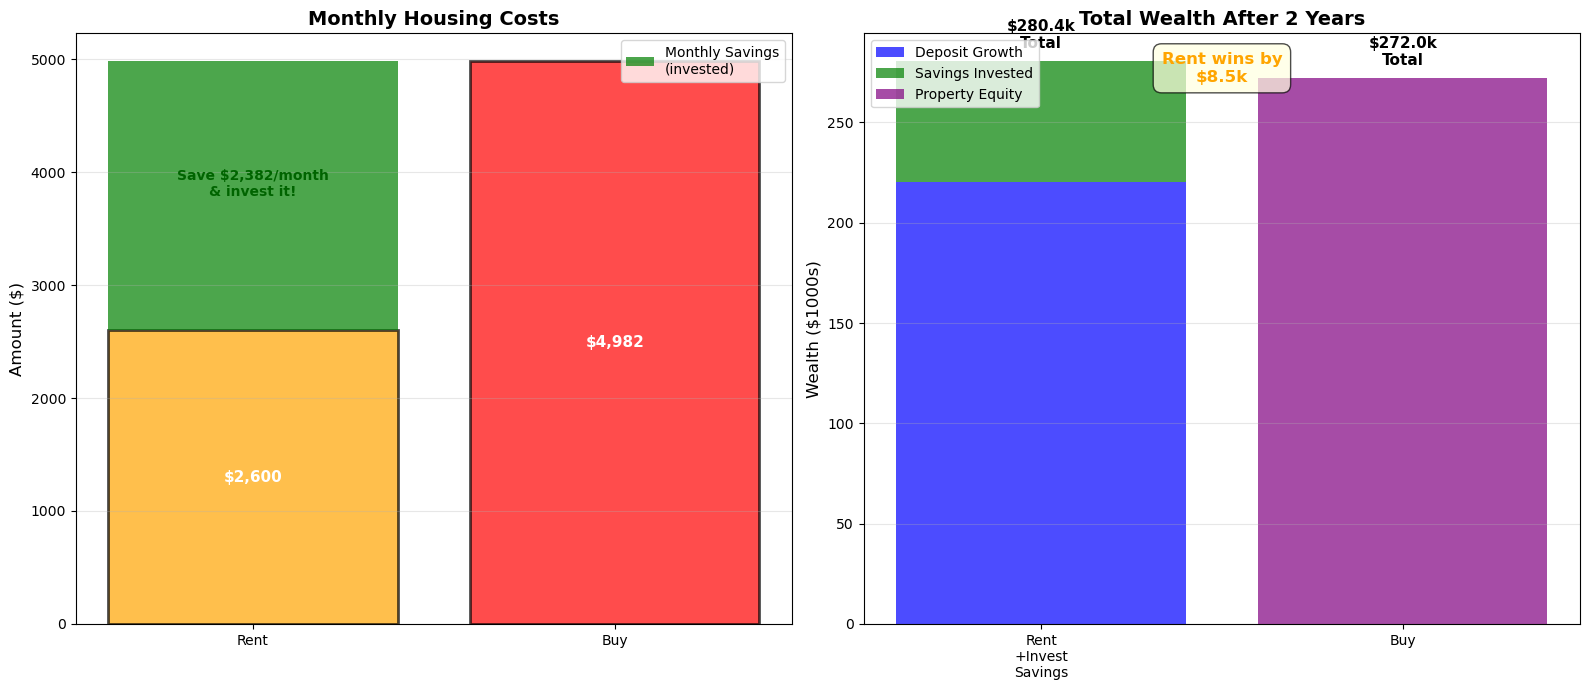


BREAKDOWN: Where does the wealth come from?

Rent scenario total: $280,436
  = $220,500 (deposit growth)
  + $59,936 (monthly savings invested)

Buy scenario total: $271,958
  = $271,958 (equity)

💰 Property equity is $51,458 higher than deposit growth
   But you invested $59,936 in monthly savings
   Net advantage: $-8,479

🎯 Property LEVERAGE effect:
   Your $200,000 controls a $850,000 asset
   3.0% growth on $850,000 = $51,000 over 2 years
   vs 5.0% growth on $200,000 + savings = $80,436 gains


In [20]:
import matplotlib.pyplot as plt
# Visualize the fair comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# LEFT: Monthly cash flow comparison
ax1.set_title(f'Monthly Housing Costs', fontsize=14, fontweight='bold')
categories = ['Rent', 'Buy']
costs = [result_fair['monthly_rent'], result_fair['monthly_total_buy']]
colors_bar = ['orange', 'red']

bars = ax1.bar(categories, costs, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)

# Show the savings
ax1.bar(['Rent'], [result_fair['monthly_savings']], 
        bottom=[result_fair['monthly_rent']], 
        color='green', alpha=0.7, label='Monthly Savings\n(invested)')

ax1.set_ylabel('Amount ($)', fontsize=12)
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Add cost labels
for i, (cat, cost) in enumerate(zip(categories, costs)):
    ax1.text(i, cost/2, f'${cost:,.0f}', 
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')

# Add savings annotation
ax1.annotate(f'Save ${result_fair["monthly_savings"]:,.0f}/month\n& invest it!', 
            xy=(0, result_fair['monthly_rent'] + result_fair['monthly_savings']/2), 
            fontsize=10, fontweight='bold', color='darkgreen', ha='center')

# RIGHT: Final wealth comparison
ax2.set_title('Total Wealth After 2 Years', fontsize=14, fontweight='bold')
scenarios = ['Rent\n+Invest\nSavings', 'Buy']
wealth_values = [result_fair['total_wealth_rent']/1000, result_fair['total_wealth_buy']/1000]

# Stacked bars showing components
ax2.bar([0], [result_fair['invested_deposit_value']/1000], 
        color='blue', alpha=0.7, label='Deposit Growth')
ax2.bar([0], [result_fair['savings_invested']/1000], 
        bottom=[result_fair['invested_deposit_value']/1000],
        color='green', alpha=0.7, label='Savings Invested')
ax2.bar([1], [result_fair['equity']/1000], 
        color='purple', alpha=0.7, label='Property Equity')

ax2.set_ylabel('Wealth ($1000s)', fontsize=12)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(scenarios)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3, axis='y')

# Add total labels
for i, val in enumerate(wealth_values):
    ax2.text(i, val + 5, f'${val:.1f}k\nTotal', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Show difference
diff = result_fair['wealth_difference']
if diff > 0:
    ax2.annotate(f'Buy wins by\n${diff/1000:.1f}k', 
                xy=(0.5, max(wealth_values) - 10), 
                fontsize=12, fontweight='bold', color='green', ha='center',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7))
else:
    ax2.annotate(f'Rent wins by\n${-diff/1000:.1f}k', 
                xy=(0.5, max(wealth_values) - 10), 
                fontsize=12, fontweight='bold', color='orange', ha='center',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("BREAKDOWN: Where does the wealth come from?")
print("="*70)
print(f"\nRent scenario total: ${result_fair['total_wealth_rent']:,.0f}")
print(f"  = ${result_fair['invested_deposit_value']:,.0f} (deposit growth)")
print(f"  + ${result_fair['savings_invested']:,.0f} (monthly savings invested)")

print(f"\nBuy scenario total: ${result_fair['total_wealth_buy']:,.0f}")
print(f"  = ${result_fair['equity']:,.0f} (equity)")

print(f"\n💰 Property equity is ${result_fair['equity'] - result_fair['invested_deposit_value']:,.0f} higher than deposit growth")
print(f"   But you invested ${result_fair['savings_invested']:,.0f} in monthly savings")
print(f"   Net advantage: ${result_fair['wealth_difference']:,.0f}")

print(f"\n🎯 Property LEVERAGE effect:")
print(f"   Your ${deposit:,.0f} controls a ${property_price:,.0f} asset")
print(f"   {property_growth_rate*100:.1f}% growth on ${property_price:,.0f} = ${property_price * property_growth_rate * 2:,.0f} over 2 years")
print(f"   vs {investment_return_rate*100:.1f}% growth on ${deposit:,.0f} + savings = ${result_fair['total_wealth_rent'] - deposit:,.0f} gains")